In [ ]:
!pip install pandas
!pip install tensorflow<2.11
!pip install numpy<2

/bin/bash: line 1: 2.11: No such file or directory
/bin/bash: line 1: 2: No such file or directory


In [ ]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np

In [ ]:
df = pd.read_csv("/content/train.csv")

In [ ]:
from tensorflow.keras.layers import TextVectorization

In [ ]:
X = df['comment_text']
y = df[df.columns[2:]].values

In [ ]:
MAX_FEATURES = 200000 # number of words in the vocab

In [ ]:
vectorizer = TextVectorization(max_tokens=MAX_FEATURES,
                               output_sequence_length=1800,
                               output_mode='int')

In [ ]:
vectorizer.adapt(X.values)

In [ ]:
print(vectorizer)

<TextVectorization name=text_vectorization, built=False>


In [ ]:
vectorized_text = vectorizer(X.values)

In [ ]:
#MCSHBAP - map, cache, shuffle, batch, prefetch  from_tensor_slices, list_file
dataset = (
    tf.data.Dataset.from_tensor_slices((vectorized_text, y))
      .cache()
      .shuffle(160000)
      .batch(16)
      .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
batch_X, batch_y = dataset.as_numpy_iterator().next()

In [ ]:
train = dataset.take(int(len(dataset)*.7))
val = dataset.skip(int(len(dataset)*.7)).take(int(len(dataset)*.2))
test = dataset.skip(int(len(dataset)*.9)).take(int(len(dataset)*.1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Embedding
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))






Num GPUs Available: 1


In [ ]:
model = Sequential()
# Create the embedding layer
model.add(Embedding(MAX_FEATURES+1, 32))
# Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(32, activation='tanh')))
# Feature extractor Fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
# Final layer
model.add(Dense(6, activation='sigmoid'))

In [ ]:
model.compile(loss=tf.keras.losses.binary_crossentropy, optimizer='Adam')


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train, epochs=12, validation_data=val)

Epoch 1/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 708s 101ms/step - loss: 0.0702 - val_loss: 0.0440
Epoch 2/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 706s 101ms/step - loss: 0.0464 - val_loss: 0.0409
Epoch 3/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 746s 102ms/step - loss: 0.0406 - val_loss: 0.0373
Epoch 4/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 739s 101ms/step - loss: 0.0357 - val_loss: 0.0313
Epoch 5/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 741s 101ms/step - loss: 0.0320 - val_loss: 0.0278
Epoch 6/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 708s 101ms/step - loss: 0.0288 - val_loss: 0.0250
Epoch 7/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 706s 101ms/step - loss: 0.0257 - val_loss: 0.0239
Epoch 8/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 700s 100ms/step - loss: 0.0235 - val_loss: 0.0200
Epoch 9/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 734s 99ms/step - loss: 0.0205 - val_loss: 0.0202
Epoch 10/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 709s 102ms/step - loss: 0.0190 - val_loss: 0.0167
Epoch 11/12
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 714s 102ms/step - loss: 0.0162 - val_

<Figure size 800x500 with 0 Axes>

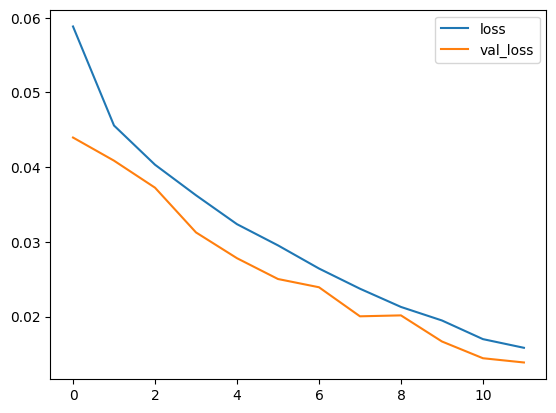

In [ ]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))
pd.DataFrame(history.history).plot()
plt.show()

In [ ]:
model.save("/home/toxicity_epochs12.keras")

In [ ]:
input_text = vectorizer("You are a piece of shit.")

In [ ]:
res = model.predict(np.expand_dims(input_text,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


In [ ]:
df.columns[2:]
print(res)
(res > 0.5).astype(int)

[[0.9980247  0.05091266 0.97867143 0.00415941 0.9528654  0.00289819]]


array([[1, 0, 1, 0, 1, 0]])

In [ ]:
batch=test.as_numpy_iterator().next()
batch_X, batch_y = test.as_numpy_iterator().next()

In [ ]:
model.predict(batch_X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


array([[6.90870934e-08, 8.14513996e-19, 1.46013477e-07, 9.42172651e-09,
        3.46796231e-10, 5.62366180e-13],
       [2.01751632e-07, 3.86262616e-18, 2.30750189e-07, 1.02723279e-08,
        2.57072119e-09, 1.00494855e-11],
       [6.32816600e-03, 6.73191414e-09, 7.73195177e-04, 7.76953821e-05,
        8.49763281e-04, 9.06273090e-06],
       [7.68602206e-07, 1.02782247e-16, 1.99733017e-06, 6.49694343e-08,
        2.43348861e-08, 3.67694486e-11],
       [1.12348690e-03, 2.73484488e-08, 8.92210868e-04, 2.94451078e-04,
        9.84648141e-05, 1.18583957e-05],
       [1.73248030e-04, 1.17371174e-12, 2.31412869e-05, 1.56887756e-06,
        7.28658824e-06, 3.99975804e-08],
       [3.62779174e-05, 2.46282053e-13, 1.08406202e-05, 5.11285589e-06,
        8.30126339e-07, 2.05126351e-08],
       [4.50755145e-12, 4.06303156e-27, 2.75440348e-11, 2.49245015e-13,
        6.33522940e-16, 1.27675987e-19],
       [1.93619107e-05, 1.78860019e-13, 2.92104669e-05, 2.69402506e-07,
        1.51447773e-06, 

In [ ]:
(model.predict(batch_X) > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 1, 1],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])

In [ ]:
res.shape

(1, 6)

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy

In [ ]:
pre = Precision()
re = Recall()
acc = CategoricalAccuracy()

In [ ]:
for batch in test.as_numpy_iterator():
    # Unpack the batch
    X_true, y_true = batch
    # Make a prediction
    yhat = model.predict(X_true)

    # Flatten the predictions
    y_true = y_true.flatten()
    yhat = yhat.flatten()

    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    acc.update_state(y_true, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━

In [ ]:
print(f'Precision: {pre.result().numpy()}, Recall:{re.result().numpy()}, Accuracy:{acc.result().numpy()}')

Precision: 0.9430110454559326, Recall:0.912983775138855, Accuracy:0.4613841474056244
